In [13]:
import tqdm
import torch
import numpy as np
from torch import nn

In [14]:
class TemperatureFFN(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 128),

            nn.ReLU(),

            nn.Linear(128, 64),

            nn.ReLU(),

            nn.Linear(64, 32),

            nn.ReLU(),

            nn.Linear(32, 1)

        )

        

    def forward(self, x):

        # x dolazi kao [batch_size, lookback, 1] -> menjamo u [batch_size, lookback]

        # Ako je lookback=1, ovo postaje [batch_size, 1] što nn.Linear savršeno razume

        if x.dim() == 3:

            x = x.squeeze(-1) 

        return self.network(x)


In [52]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df=pd.read_csv("/home/polaznik/Desktop/nevena/TemperatureForecasting/real_data/petnica_data.csv")

#print(df.head())



#df = df.iloc[600:]



#df = df.reset_index(drop=True)

total_missing_rows = df.isna().any(axis=1).sum()

print("hello nema ovoliko", total_missing_rows)



#print(df.head())





df["date"] = pd.to_datetime(df["date"])

#print(df["date"].dtype)



timeseries = df[["temperature_2m"]].values.astype('float32')



trening_skup = df.loc[df["date"] < "2024-08-14", ["temperature_2m"]].values.astype("float32")



validacija_skup = df.loc[

    (df["date"] >= "2024-08-14") & (df["date"] < "2025-08-14"),

    ["temperature_2m"]

].values.astype("float32")



test_skup = df.loc[

    df["date"] >= "2025-08-14",

    ["temperature_2m"]

].values.astype("float32")



#skaliranje

scaler = StandardScaler()

trening = scaler.fit_transform(trening_skup)

validacija = scaler.transform(validacija_skup)

test = scaler.transform(test_skup)

timeseries_scaled = scaler.transform(timeseries) # Potrebno za kasnije plotovanje cele serije





import torch

 

def create_dataset(dataset, lookback):

    """Transform a time series into a prediction dataset

    

    Args:

        dataset: A numpy array of time series, first dimension is the time steps

        lookback: Size of window for prediction

    """

    X, y = [], []

    for i in range(len(dataset)-lookback):

        feature = dataset[i:i+lookback]

        target = dataset[i+lookback:i+lookback+1]

        X.append(feature)

        y.append(target)



    X = np.array(X, dtype=np.float32)

    y = np.array(y, dtype=np.float32)

        

    return torch.tensor(X), torch.tensor(y)



lookback = 200

X_train, y_train = create_dataset(trening, lookback=lookback)


hello nema ovoliko 25675


In [66]:

X_train, y_train = create_dataset(trening, lookback=lookback)
X_val, y_val = create_dataset(validacija, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)

X_train.squeeze(-1)

tensor([[-0.5307, -0.5081, -0.4288,  ..., -2.1098, -2.1268, -2.0419],
        [-0.5081, -0.4288, -0.4571,  ..., -2.1268, -2.0419, -1.7306],
        [-0.4288, -0.4571, -0.4515,  ..., -2.0419, -1.7306, -1.5381],
        ...,
        [ 1.5351,  1.6709,  1.6936,  ...,  1.7275,  1.4672,  1.4898],
        [ 1.6709,  1.6936,  1.6257,  ...,  1.4672,  1.4898,  1.4898],
        [ 1.6936,  1.6257,  1.5011,  ...,  1.4898,  1.4898,  1.3993]])

In [55]:
model = TemperatureFFN(lookback)
model.load_state_dict(torch.load("fnn.pt"))

<All keys matched successfully>

In [59]:

# Predikcije u buducnost
model.eval()
predictions = []
time_steps = 10000
with torch.no_grad():
    current_temps = X_train[-1, :, :]
    for i in tqdm.tqdm(range(time_steps)):
        next_temp = model(current_temps.T)
        predictions.append(scaler.inverse_transform(next_temp))
        current_temps = torch.roll(current_temps, -1)
        current_temps[-1] = next_temp.item()

100%|██████████| 10000/10000 [00:04<00:00, 2050.29it/s]


In [60]:
predictions = np.array(predictions)
predictions.shape

(10000, 1, 1)

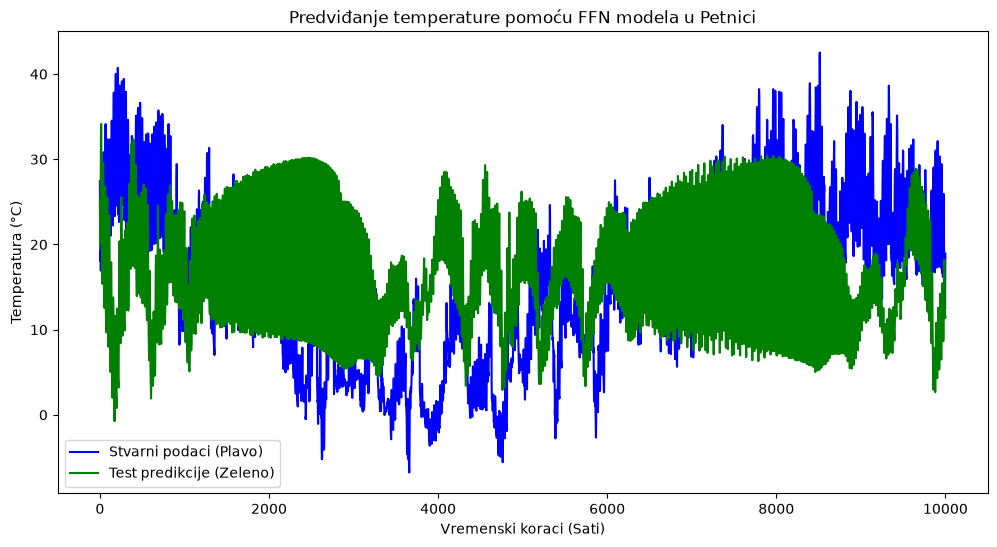

In [61]:
from matplotlib import pyplot as plt

test_timestemp = len(X_train)+1

plt.figure(figsize=(12, 6))
plt.plot(timeseries[test_timestemp:test_timestemp+time_steps], c='b', label='Stvarni podaci (Plavo)')
plt.plot(predictions.squeeze(), c='g', label='Test predikcije (Zeleno)')
plt.title("Predviđanje temperature pomoću FFN modela u Petnici")
plt.xlabel("Vremenski koraci (Sati)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.savefig("predikcije_buducnost.png")
plt.show()